
# 14_td3_ddpg_reacher.ipynb — Phase 1 (TD3 vs DDPG on Reacher-v4, SB3)

**Tam uyumlu klasör şeması**:
```
runs/Phase 1/14_td3_ddpg_reacher/<RUN_ID>/
  ├─ monitor/
  ├─ checkpoints/
  ├─ TD3_Reacher_v4/
  └─ DDPG_Reacher_v4/
```
Tüm loglar **yalnızca** bu ağaç altına yazılır.


## 1) Kurulum (gerekiyorsa)

In [1]:

# %pip install -U "stable-baselines3>=2.3.0" "gymnasium[mujoco]" mujoco tensorboard pandas matplotlib tqdm


## 2) Kütüphaneler ve Sürüm Bilgisi

In [2]:

import os, time, uuid, json, random, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, gymnasium as gym, stable_baselines3 as sb3
from stable_baselines3 import TD3, DDPG
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.logger import configure
from stable_baselines3.common.utils import set_random_seed
from tensorboard.backend.event_processing import event_accumulator as ea

print("Gym:", gym.__version__, "| SB3:", sb3.__version__, "| Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available(), "| MPS:", torch.backends.mps.is_available())


Gym: 1.1.1 | SB3: 2.6.0 | Torch: 2.7.1
CUDA: False | MPS: True


## 3) Konfigürasyon & Dizinler — *Phase 1 formatına sabit*

In [3]:

PHASE    = "Phase 1"
STEP     = "TD3vsDDPG-Reacher"
NOTEBOOK = "14_td3_ddpg_reacher"
ENV_ID   = "Reacher-v5"

SEED = 42
TOTAL_STEPS = 500_000
EVAL_FREQ   = 20_000
SAVE_FREQ   = 100_000

NET_ARCH = [256, 256]
TD3_CFG = dict(learning_rate=1e-3, buffer_size=1_000_000, batch_size=256, tau=0.005, gamma=0.99,
               train_freq=(1,"step"), gradient_steps=-1, policy_kwargs=dict(net_arch=NET_ARCH), verbose=1)
DDPG_CFG = dict(learning_rate=1e-3, buffer_size=1_000_000, batch_size=256, tau=0.005, gamma=0.99,
                train_freq=(1,"step"), gradient_steps=-1, policy_kwargs=dict(net_arch=NET_ARCH), verbose=1)

RUN_ID    = time.strftime('%Y%m%d-%H%M%S') + f"-{uuid.uuid4().hex[:6]}"
ROOT_DIR  = os.path.join("runs", PHASE, NOTEBOOK, RUN_ID)
CKPT_DIR  = os.path.join(ROOT_DIR, "checkpoints")
MON_DIR   = os.path.join(ROOT_DIR, "monitor")
os.makedirs(CKPT_DIR, exist_ok=True); os.makedirs(MON_DIR,  exist_ok=True)
set_random_seed(SEED); np.random.seed(SEED); random.seed(SEED)

TD3_DIR   = os.path.join(ROOT_DIR, f"TD3_{ENV_ID.replace('-','_')}")
DDPG_DIR  = os.path.join(ROOT_DIR, f"DDPG_{ENV_ID.replace('-','_')}")
os.makedirs(TD3_DIR, exist_ok=True); os.makedirs(DDPG_DIR, exist_ok=True)

print("ROOT_DIR:", ROOT_DIR)
print("  CKPT_DIR:", CKPT_DIR)
print("  MON_DIR :", MON_DIR)
print("  TD3_DIR :", TD3_DIR)
print("  DDPG_DIR:", DDPG_DIR)


ROOT_DIR: runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0
  CKPT_DIR: runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0/checkpoints
  MON_DIR : runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0/monitor
  TD3_DIR : runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0/TD3_Reacher_v5
  DDPG_DIR: runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0/DDPG_Reacher_v5


## 4) Ortam — Monitor her zaman `runs/Phase 1/.../monitor/` içine yazar

In [4]:

def make_env(env_id=ENV_ID, render=False):
    env = gym.make(env_id, render_mode="human") if render else gym.make(env_id)
    md = os.path.join(MON_DIR, env_id.replace("-", "_"))
    os.makedirs(md, exist_ok=True)
    env = Monitor(env, md)
    return env

# hızlı kontrol
_env = make_env(render=False); obs, _ = _env.reset(seed=SEED)
print("Obs:", np.array(obs).shape, "| Act:", _env.action_space); _env.close()


Obs: (10,) | Act: Box(-1.0, 1.0, (2,), float32)


## 5) Eğitim Fonksiyonu — logger dizinleri **sabit**

In [5]:

def train_one(algo: str, total_steps: int = TOTAL_STEPS, seed: int = SEED):
    assert algo in ("TD3","DDPG")
    env = make_env(render=False)
    eval_env = gym.make(ENV_ID)  # monitorsuz

    if algo == "TD3":
        Model, cfg, log_dir = TD3, TD3_CFG, TD3_DIR
    else:
        Model, cfg, log_dir = DDPG, DDPG_CFG, DDPG_DIR

    logger = configure(log_dir, ["stdout","csv","tensorboard"])
    model = Model("MlpPolicy", env, device="auto", seed=seed, **cfg)
    model.set_logger(logger)

    base = f"{algo}_{ENV_ID.replace('-','_')}"
    eval_cb = EvalCallback(eval_env,
                           best_model_save_path=os.path.join(CKPT_DIR, base),
                           log_path=log_dir, eval_freq=EVAL_FREQ,
                           n_eval_episodes=5, deterministic=True)
    ckpt_cb = CheckpointCallback(save_freq=SAVE_FREQ,
                                 save_path=os.path.join(CKPT_DIR, base),
                                 name_prefix="ckpt")

    print(f"[TRAIN] {algo} | env={ENV_ID} | steps={total_steps}")
    print("  log_dir  ->", log_dir)
    print("  ckpt_dir ->", os.path.join(CKPT_DIR, base))
    print("  monitor  ->", os.path.join(MON_DIR, ENV_ID.replace('-','_')))

    model.learn(total_timesteps=total_steps, callback=[eval_cb, ckpt_cb], progress_bar=True)

    final_path = os.path.join(CKPT_DIR, base, f"final_{algo.lower()}.zip")
    os.makedirs(os.path.dirname(final_path), exist_ok=True)
    model.save(final_path)
    print("[DONE] Saved:", final_path)

    mean_r, std_r = evaluate_policy(model, eval_env, n_eval_episodes=10, deterministic=True)
    print(f"[EVAL] {algo} | MeanReturn={mean_r:.1f} ± {std_r:.1f}")

    env.close(); eval_env.close()
    return log_dir


## 6) Eğitimleri Başlat

In [6]:

TB_DIRS = {"TD3": train_one("TD3"), "DDPG": train_one("DDPG")}
print("TB_DIRS:", TB_DIRS)


Logging to runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0/TD3_Reacher_v5
Using cpu device
Wrapping the env in a DummyVecEnv.


Output()

[TRAIN] TD3 | env=Reacher-v5 | steps=500000
  log_dir  -> runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0/TD3_Reacher_v5
  ckpt_dir -> runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0/checkpoints/TD3_Reacher_v5
  monitor  -> runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0/monitor/Reacher_v5


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -70.8    |
| time/              |          |
|    episodes        | 4        |
|    fps             | 239      |
|    time_elapsed    | 0        |
|    total_timesteps | 200      |
| train/             |          |
|    actor_loss      | 3.12     |
|    critic_loss     | 0.269    |
|    learning_rate   | 0.001    |
|    n_updates       | 99       |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -59      |
| time/              |          |
|    episodes        | 8        |
|    fps             | 182      |
|    time_elapsed    | 2        |
|    total_timesteps | 400      |
| train/             |          |
|    actor_loss      | 1.82     |
|    critic_loss     | 0.0458   |
|    learning_rate   | 0.001    |
|    n_updates       | 299      |
---------------------------------


...

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -4.98    |
| time/              |          |
|    episodes        | 9996     |
|    fps             | 173      |
|    time_elapsed    | 2881     |
|    total_timesteps | 499800   |
| train/             |          |
|    actor_loss      | 1.06     |
|    critic_loss     | 0.0122   |
|    learning_rate   | 0.001    |
|    n_updates       | 499699   |
---------------------------------


Eval num_timesteps=500000, episode_reward=-3.84 +/- 0.95

Episode length: 50.00 +/- 0.00

---------------------------------
| eval/              |          |
|    mean_ep_length  | 50       |
|    mean_reward     | -3.84    |
| time/              |          |
|    total_timesteps | 500000   |
| train/             |          |
|    actor_loss      | 0.929    |
|    critic_loss     | 0.0076   |
|    learning_rate   | 0.001    |
|    n_updates       | 499899   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -4.95    |
| time/              |          |
|    episodes        | 10000    |
|    fps             | 173      |
|    time_elapsed    | 2883     |
|    total_timesteps | 500000   |
---------------------------------


[DONE] Saved: runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0/checkpoints/DDPG_Reacher_v5/final_ddpg.zip
[EVAL] DDPG | MeanReturn=-4.5 ± 1.4
TB_DIRS: {'TD3': 'runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0/TD3_Reacher_v5', 'DDPG': 'runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0/DDPG_Reacher_v5'}


## 7) `progress.csv` Karşılaştırması

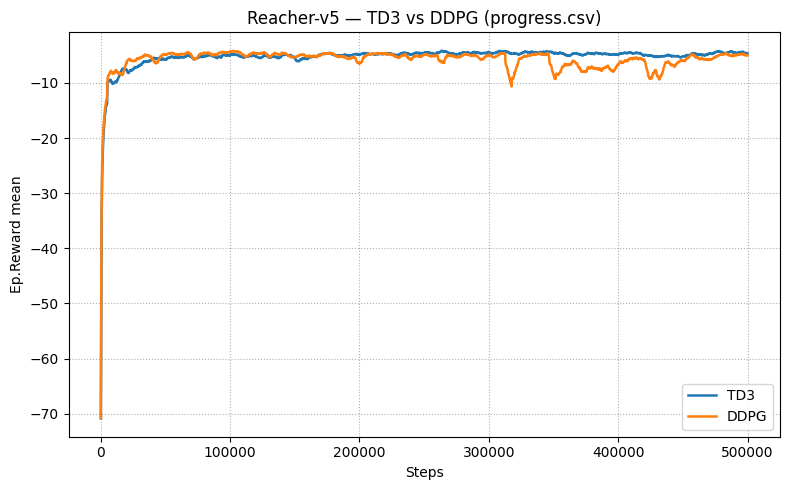

In [7]:

def plot_progress(tb_dirs: dict):
    plt.figure(figsize=(8,5))
    for algo, d in tb_dirs.items():
        csv = os.path.join(d, "progress.csv")
        if not os.path.exists(csv):
            print("[WARN] progress yok:", algo, csv); continue
        df = pd.read_csv(csv)
        x = next((c for c in ["time/total_timesteps","timesteps","total_timesteps"] if c in df.columns), None)
        y = next((c for c in ["rollout/ep_rew_mean","ep_rew_mean"] if c in df.columns), None)
        if not (x and y): continue
        plt.plot(df[x], df[y], label=algo, linewidth=1.8)
    plt.title(f"{ENV_ID} — TD3 vs DDPG (progress.csv)")
    plt.xlabel("Steps"); plt.ylabel("Ep.Reward mean"); plt.grid(True, linestyle=":"); plt.legend(); plt.tight_layout(); plt.show()

plot_progress(TB_DIRS)


## 8) TensorBoard `eval/mean_reward` Karşılaştırması

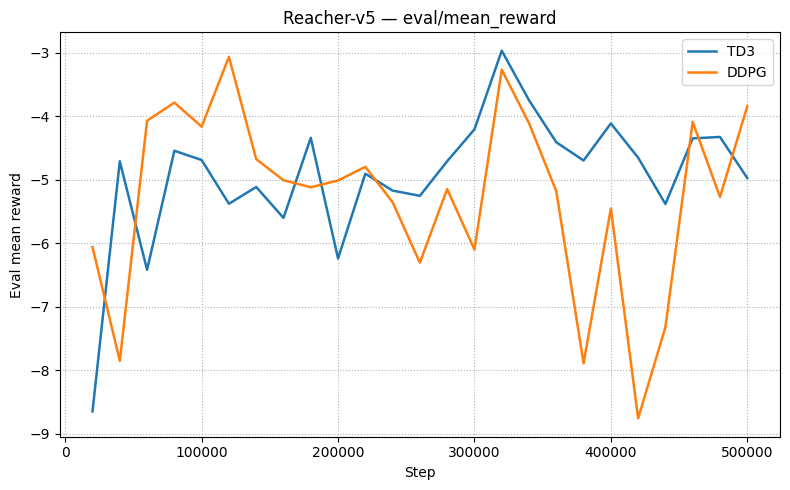

In [8]:

def tb_series(run_dir: str, tag: str):
    files = [os.path.join(r,f) for r,_,fs in os.walk(run_dir) for f in fs if f.startswith("events.out.tfevents")]
    if not files: return pd.DataFrame(columns=["step","val"])
    dfs=[]
    for f in files:
        try:
            acc = ea.EventAccumulator(f, size_guidance={"scalars": 10**7}); acc.Reload()
            if tag in acc.Tags().get("scalars", []):
                s = acc.Scalars(tag)
                dfs.append(pd.DataFrame({"step":[i.step for i in s], "val":[i.value for i in s]}))
        except Exception as ex:
            print("[WARN] TB okunamadı:", f, ex)
    if not dfs: return pd.DataFrame(columns=["step","val"])
    out = pd.concat(dfs).groupby("step", as_index=False)["val"].mean().sort_values("step")
    return out

plt.figure(figsize=(8,5))
for algo, d in TB_DIRS.items():
    df = tb_series(d, "eval/mean_reward")
    if len(df): plt.plot(df["step"], df["val"], label=algo, linewidth=1.8)
plt.title(f"{ENV_ID} — eval/mean_reward"); plt.xlabel("Step"); plt.ylabel("Eval mean reward")
plt.grid(True, linestyle=":"); plt.legend(); plt.tight_layout(); plt.show()


## 9) Render Demo (isteğe bağlı)

In [12]:

def render_demo(algo: str, episodes: int = 3):
    base = f"{algo}_{ENV_ID.replace('-','_')}"
    path = os.path.join(CKPT_DIR, base, f"final_{algo.lower()}.zip")
    if not os.path.exists(path):
        print("[WARN] Model yok:", path); return
    try:
        env = gym.make(ENV_ID, render_mode="human")
    except TypeError:
        env = gym.make(ENV_ID)
    Model = TD3 if algo=="TD3" else DDPG
    model = Model.load(path, env=env, device="auto")
    for ep in range(episodes):
        obs,_=env.reset(seed=SEED+ep); done=trunc=False; ret=0.0
        while not (done or trunc):
            act,_ = model.predict(obs, deterministic=True)
            obs,r,done,trunc,_ = env.step(act); ret += r
        print(f"[RENDER] {algo} Ep{ep+1}: Return={ret:.1f}")
    env.close()

render_demo("TD3"); render_demo("DDPG")


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
[RENDER] TD3 Ep1: Return=-3.3
[RENDER] TD3 Ep2: Return=-3.6
[RENDER] TD3 Ep3: Return=-5.8
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
[RENDER] DDPG Ep1: Return=-2.1
[RENDER] DDPG Ep2: Return=-4.9
[RENDER] DDPG Ep3: Return=-5.5


## 10) Meta Bilgi

In [10]:

meta = {"phase":PHASE,"step":STEP,"notebook":NOTEBOOK,"env":ENV_ID,"seed":SEED,
        "run_id":RUN_ID,"root_dir":ROOT_DIR,"ckpt_dir":CKPT_DIR,"monitor_dir":MON_DIR,
        "td3_dir":TD3_DIR,"ddpg_dir":DDPG_DIR}
with open(os.path.join(ROOT_DIR, "meta.json"), "w") as f: json.dump(meta, f, indent=2)
print(json.dumps(meta, indent=2))


{
  "phase": "Phase 1",
  "step": "TD3vsDDPG-Reacher",
  "notebook": "14_td3_ddpg_reacher",
  "env": "Reacher-v5",
  "seed": 42,
  "run_id": "20251003-162719-9e6ce0",
  "root_dir": "runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0",
  "ckpt_dir": "runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0/checkpoints",
  "monitor_dir": "runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0/monitor",
  "td3_dir": "runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0/TD3_Reacher_v5",
  "ddpg_dir": "runs/Phase 1/14_td3_ddpg_reacher/20251003-162719-9e6ce0/DDPG_Reacher_v5"
}
